Part 3: NLP and Sequence Modeling Mini Project


Number of Records in the Dataset: 1500

Target Column:
sentiment_label

Target Classes:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Sample Text Records:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str

Average Text Length:
12.722666666666667

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


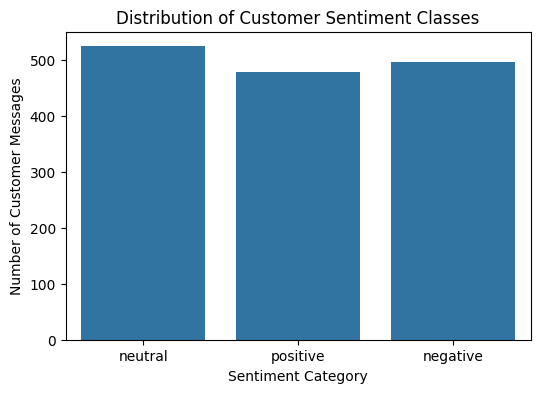

In [1]:
## Task 1: Dataset Understanding

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

customer_support_data = pd.read_csv("customer_support_text_classification.csv")

# Number of records

num_records = len(customer_support_data)
print(f'\nNumber of Records in the Dataset: {num_records}')

target_column = "sentiment_label"

print("\nTarget Column:")
print(target_column)

# Target labels/classes
print("\nTarget Classes:")
print(customer_support_data['sentiment_label'].unique())

# Sample text records

print("\nSample Text Records:")
print(customer_support_data['customer_message'].head())

# Average text length

print("\nAverage Text Length:")
print(customer_support_data['word_count'].mean())

# Class distribution
print("\nClass Distribution:")
print(customer_support_data[target_column].value_counts())

# Visualize Class Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x = target_column,
    data = customer_support_data
)

plt.title("Distribution of Customer Sentiment Classes")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Customer Messages")

plt.show()


In [2]:
## Task 2: Text Preprocessing

# Import libraries
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Downloading required NLTK Files
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Define Stopwords
stop_words = set(stopwords.words('english'))

# Text Cleaning Function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back into sentence
    cleaned_text = " ".join(tokens)

    return(cleaned_text)

# Apply Preprocessing
customer_support_data['cleaned_message'] = customer_support_data['customer_message'].astype(str).apply(preprocess_text)

# View Original vs Cleaned Text

print("\nOriginal Message:\n")
print(customer_support_data['customer_message'].iloc[0])

print("\nCleaned Message:\n")
print(customer_support_data['cleaned_message'].iloc[0])

# Tokenizer for Sequence Models
tokenizer = Tokenizer(num_words = 5000)

# Fit tokenizer on cleaned text
tokenizer.fit_on_texts(customer_support_data['cleaned_message'])


# Convert text to sequences
sequences = tokenizer.texts_to_sequences(customer_support_data['cleaned_message'])

# Padding / Truncating Sequences
max_length = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen = max_length,
    padding = 'post',
    truncating = 'post'
)

# Display Example
print("\nExample Sequence:\n")
print(sequences[0])

print("\nPadded Sequence:\n")
print(padded_sequences[0])

print("\nShape of Padded Sequences:")
print(padded_sequences.shape)




Original Message:

I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Cleaned Message:

need information payment process ticket number please respond soon possible

Example Sequence:

[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]

Padded Sequence:

[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]

Shape of Padded Sequences:
(1500, 50)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\natas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\natas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\natas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
## Task 3: Text Vectorization

# Import libraries
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Converting text into numerical format 

# 1. Bag of Words Vectorization

bow_vectorizer = CountVectorizer(max_features=5000)

X_bow = bow_vectorizer.fit_transform(customer_support_data['cleaned_message'])

print("Bag of Words Shape:")
print(X_bow.shape)

# 2. TF-IDF Vectorization

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf_vectorizer.fit_transform(customer_support_data['cleaned_message'])

print('\nTF-IDF Shape:')
print(X_tfidf.shape)

# Display Sample Features
print('\nSample TF-IDF Features:')
print(tfidf_vectorizer.get_feature_names_out()[:20])

# Example Vector
print("\nExample TF-IDF Vector:")
print(X_tfidf[0].toarray())


Bag of Words Shape:
(1500, 146)

TF-IDF Shape:
(1500, 146)

Sample TF-IDF Features:
['account' 'activate' 'ago' 'analytics' 'app' 'appreciate' 'arrived'
 'assigned' 'available' 'bad' 'billing' 'call' 'cancel' 'care' 'charged'
 'checking' 'clear' 'communication' 'completed' 'confirm']

Example TF-IDF Vector:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.44084662 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.35345568 0.         0.
  0.         0.20627565 0.     

### Explain why text must be converted into vectors before being used by a model.

Text must be converted into vectors because machine learning models cannot understand text directly. Models work only with numerical data.
Text vectorization converts words and sentences into numbers so the model can process, analyze, and learn patterns from the data.

Accuracy Score:
1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Confusion Matrix:
[[109   0   0]
 [  0 104   0]
 [  0   0  87]]
Results saved successfully in the results folder.


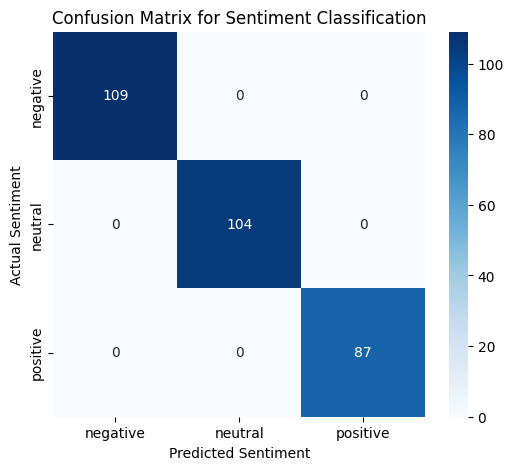

In [4]:
## Task 4: Baseline Model

# Logistic Regression with TF-IDF

# Import libraries
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Define Features and Target
X = X_tfidf
y = customer_support_data['sentiment_label']

# Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

# Build Logistic Regression Model
model = LogisticRegression()

# Train model
model.fit(X_train,y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
print("Accuracy Score:")
print(accuracy_score(y_test,y_pred))

print('\nClassification Report:')
print(classification_report(y_test,y_pred))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test,y_pred))


# --Create results folder
os.makedirs("results",exist_ok=True)

# Define class labels
labels = ['negative', 'neutral', 'positive']

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred,labels=labels)

# Convert confusion matrix to DataFrame
cm_df = pd.DataFrame(
    cm,
    index=model.classes_,
    columns=model.classes_
)


# Plot and Save Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

# Labels and title
plt.title("Confusion Matrix for Sentiment Classification")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

# Save confusion matrix as png
plt.savefig("results/model_evaluation.png")


# Create Sample Predictions File
sample_df = pd.DataFrame(
    {
        "Customer Message":customer_support_data.loc[y_test.index,'customer_message'],
        "Actual Sentiment":y_test,
        "Predicted Sentiment":y_pred
    }
)
# Select first 10 predictions
sample_predictions = sample_df.head(10)

# Save as text file
with open("results/sample_predictions.txt", "w", encoding="utf-8") as f:

    for index,row in sample_predictions.iterrows():
        f.write(f"Customer Message: {row['Customer Message']}\n")
        f.write(f"Actual Sentiment: {row['Actual Sentiment']}\n")
        f.write(f"Predicted Sentiment: {row['Predicted Sentiment']}\n")
        f.write("-" * 50 + "\n")

print("Results saved successfully in the results folder.")


In [8]:
## Task 5: Sequence Model or Conceptual Architecture

# LSTM SEQUENCE MODEL

# Import libraries
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding,LSTM,Dense
from tensorflow.keras.utils import to_categorical

# Encode Target Labels
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(customer_support_data['sentiment_label'])

# Convert to categorical
y_categorical = to_categorical(y_encoded)

# Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(
    padded_sequences,
    y_categorical,
    test_size=0.2,
    random_state=42
)

# Build LSTM Model

model = Sequential([
    
    Input(shape=(50,)),
    
    Embedding(
        input_dim=5000,
        output_dim=64
    ),
    
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),

    Dense(64, activation='relu'),

    Dense(3, activation='softmax')
])

# Compile Model
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

# Model Summary
model.summary()

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs = 15,
    batch_size = 32,
    validation_split = 0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test,y_test)

print("\nTest Accuracy:")
print(accuracy)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 427,267 (1.63 MB)

 Trainable params: 427,267 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.3365 - loss: 1.1010 - val_accuracy: 0.3292 - val_loss: 1.0988
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3448 - loss: 1.0994 - val_accuracy: 0.3292 - val_loss: 1.1000
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3552 - loss: 1.0982 - val_accuracy: 0.3292 - val_loss: 1.0991
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3552 - loss: 1.0986 - val_accuracy: 0.3292 - val_loss: 1.0990
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3448 - loss: 1.0990 - val_accuracy: 0.3292 - val_loss: 1.0992
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3552 - loss: 1.0983 - val_accuracy: 0.3292 - val_loss: 1.0995
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3354 - loss: 1.0988 - val_accuracy: 0.3292 - val_loss: 1.0999
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3552 - loss: 1.0986 - val_accuracy: 0.3292 - v

Task 6: Attention and Transformer Reflection

1) Why RNNs struggle with long-term dependencies
RNNs struggle with long-term dependencies because they have difficulty remembering information from earlier parts of long sequences. As the sequence becomes longer, important information may be lost during processing.

2) How LSTMs help with memory
LSTMs help solve this problem by using memory cells and gates that can store and retain important information for longer periods. This allows the model to better understand context in text sequences.

3) What attention solves in sequence-to-sequence tasks
Attention mechanisms improve sequence-to-sequence tasks by allowing the model to focus on the most relevant words in the input sequence instead of relying only on previous hidden states. This improves tasks such as translation and text generation.

4) Why transformers are important in modern NLP and Generative AI
Transformers are important in modern NLP and Generative AI because they process sequences more efficiently using self-attention mechanisms. They can handle large datasets, understand context better, and power advanced AI models such as ChatGPT, translation systems, and text generation applications.